# Programa de Capacitação de Processamento Digital de Sinais

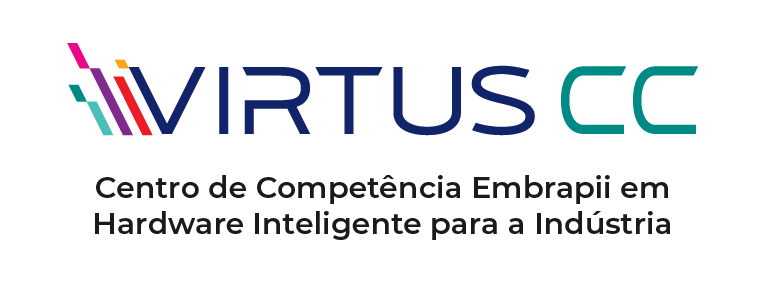


### Desenvolvido por:
-   Elmer Pimentel Farias



### Capítulos 4, 5 e 6 — Filtros Digitais  
**Baseado no livro “Processamento Digital de Sinais” — Paulo S. R. Diniz**

---

## Capítulo 4 — Filtros Digitais
O Capítulo 4 apresenta os fundamentos dos **filtros digitais**, dispositivos utilizados para modificar o espectro de um sinal de acordo com critérios de frequência.

São discutidos:
- As classificações: **passa-baixas**, **passa-altas**, **passa-faixa** e **rejeita-faixa**;  
- As diferenças entre filtros de **resposta ao impulso finita (FIR)** e **resposta ao impulso infinita (IIR)**;  
- A representação em **domínio Z**, o **diagrama de polos e zeros** e a **resposta em frequência**.

---

## Capítulo 5 — Filtros FIR
Os filtros **FIR (Finite Impulse Response)** possuem resposta ao impulso de duração finita, garantindo **estabilidade incondicional** e **fase linear**.

O capítulo enfatiza o **método de projeto por janelamento**, em especial o uso da **janela de Hamming**, que permite controlar a largura de banda e a atenuação do filtro.  
A análise da **resposta em frequência** e da **fase** é essencial para avaliar o desempenho e a seletividade do filtro.

---

## Capítulo 6 — Filtros IIR
Os filtros **IIR (Infinite Impulse Response)** são caracterizados pela **realimentação**, o que proporciona maior eficiência e seletividade espectral.  
Contudo, exigem cuidado com a **estabilidade** e a **linearidade de fase**.

São estudados os principais tipos:
- **Butterworth:** resposta suave e monotônica;  
- **Chebyshev:** maior seletividade à custa de ondulações na banda passante;  
- **Elíptico:** alta seletividade, porém com ondulações em ambas as bandas.

---

## Objetivos da Capacitação

1. **Projetar e aplicar** um **filtro FIR passa-baixas** utilizando a **janela de Hamming** em sinais ruidosos, comparando os sinais de entrada e saída.  
2. **Projetar e aplicar** um **filtro IIR Butterworth passa-altas** em sinais ruidosos, comparando os sinais de entrada e saída.  
3. **Analisar** a **resposta em frequência e fase** dos filtros projetados, avaliando suas características e desempenho.

---

*Capítulos 4, 5 e 6 — Livro “Processamento Digital de Sinais”, Paulo S. R. Diniz.*


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as signal
from numba import njit, jit , vectorize , prange
import cupy as cp
import cupyx
from scipy.signal import freqz

In [11]:
@njit(parallel=True)
def low_pass(N, fc, fs):
    """
    Calcula os coeficientes h[n] de um filtro FIR passa-baixa ideal
    usando um laço 'for' explícito.

    Argumentos:
    N (int): Ordem do filtro (número de coeficientes).
    fc (float): Frequência de corte (em Hertz).
    fs (float): Frequência de amostragem (em Hertz).

    Retorna:
    numpy.ndarray: Vetor de coeficientes h[n] do filtro.
    """
    
    # 1. CONVERSÃO: Calcula a frequência de corte digital (rad/amostra)
    #    a partir das frequências em Hertz.
    wc = 2 * np.pi * (fc / fs)
    
    # 2. Aloca um vetor 'h' vazio (cheio de zeros)
    h = np.zeros(N)
    
    # 3. Calcula o ponto médio (atraso)
    M = (N - 1) / 2
    
    # 4. Itera por cada índice 'n' do filtro
    for n in prange(N):
        # 5. Calcula o eixo 'n' centrado
        n_desloc = n - M
        
        # 6. Trata o caso especial (n = M)
        # Se n_shifted == 0, o limite é wc/pi
        if n_desloc == 0:
            h[n] = wc / np.pi
        else:
            # 7. Calcula todos os outros valores
            # Fórmula: sin(wc * n_desloc) / (pi * n_desloc)
            h[n] = np.sin(wc * n_desloc) / (np.pi * n_desloc)

    return h

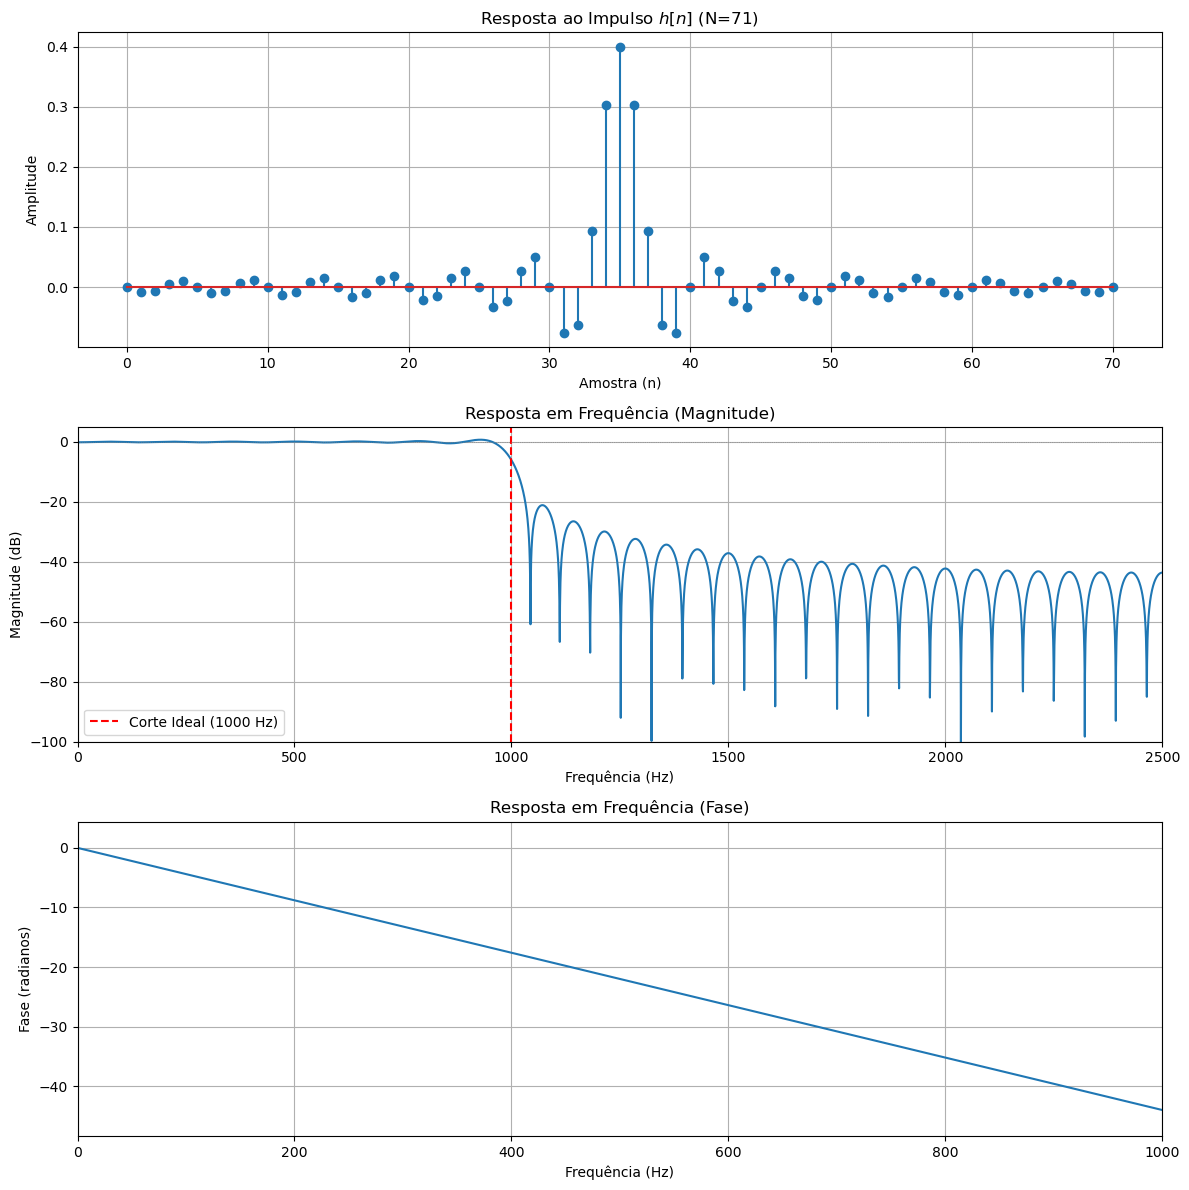

In [ ]:
# Parâmetros do Filtro
N = 71     # Ordem do filtro (número de coeficientes)
                
fs = 5000        # Frequência de amostragem (Hz)
fc = 1000        # Frequência de corte (Hz) 

#Coeficientes do filtro

h = low_pass(N, fc, fs)

# CALCULAR A RESPOSTA EM FREQUÊNCIA (W e H)
# w: vetor de frequências em rad/amostra
# H: vetor da resposta em frequência (complexa)
# worN= aumenta a resolução do gráfico
w, H = freqz(h, worN=fs)

# ---------------------------------------------------
f_hz = (w / (2 * np.pi)) * fs
db_magnitude = 20 * np.log10(np.abs(H) + 1e-9)

# Cálculo da fase
phase_rad = np.angle(H)

# np.unwrap() remove os saltos de 2*pi para vermos a linha reta
phase_unwrapped = np.unwrap(phase_rad)

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: Resposta ao Impulso (em axs[0]) 
axs[0].stem(np.arange(N), h)
axs[0].set_title(f'Resposta ao Impulso $h[n]$ (N={N})')
axs[0].set_xlabel('Amostra (n)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# Plot 2: Resposta em Frequência (Magnitude) (em axs[1]) 
axs[1].plot(f_hz, db_magnitude)
axs[1].axvline(fc, color='red', linestyle='--', label=f'Corte Ideal ({fc} Hz)')
axs[1].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axs[1].set_title('Resposta em Frequência (Magnitude)')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Magnitude (dB)')
axs[1].set_ylim(-100, 5)
axs[1].set_xlim(0, fs / 2)
axs[1].legend()
axs[1].grid(True)

# Plot 3: Resposta em Frequência (Fase) (em axs[2]) 
axs[2].plot(f_hz, phase_unwrapped)
axs[2].set_title('Resposta em Frequência (Fase)')
axs[2].set_xlabel('Frequência (Hz)')
axs[2].set_ylabel('Fase (radianos)')
# 1. Limitar o eixo X para a banda passante (0 até fc)
axs[2].set_xlim(0, fc)

# Encontra o índice do array f_hz mais próximo de fc
zoom_index_limit = np.max(np.where(f_hz <= fc))

# A fase (desembrulhada) começa em 0 e desce
min_phase = phase_unwrapped[zoom_index_limit]
max_phase = 0 # A fase em 0 Hz é 0

# 3. Adiciona uma pequena margem (10%) no eixo Y
margin = np.abs(min_phase) * 0.1
axs[2].set_ylim(min_phase - margin, max_phase + margin)

axs[2].grid(True)


plt.tight_layout() # Ajusta os plots para não sobrepor
plt.show()

In [56]:
#Janela de Hamming
@njit
def hamming_window(N):
    """
    Gera uma janela de Hamming de tamanho N.

    Argumentos:
    N (int): Tamanho da janela.

    Retorna:
    numpy.ndarray: Vetor contendo a janela de Hamming.
    """
    M = N - 1
    n = np.arange(N)
    alpha = 0.54
    window_h = alpha - (1 - alpha) * np.cos((2 * np.pi * n) / M)
    return window_h


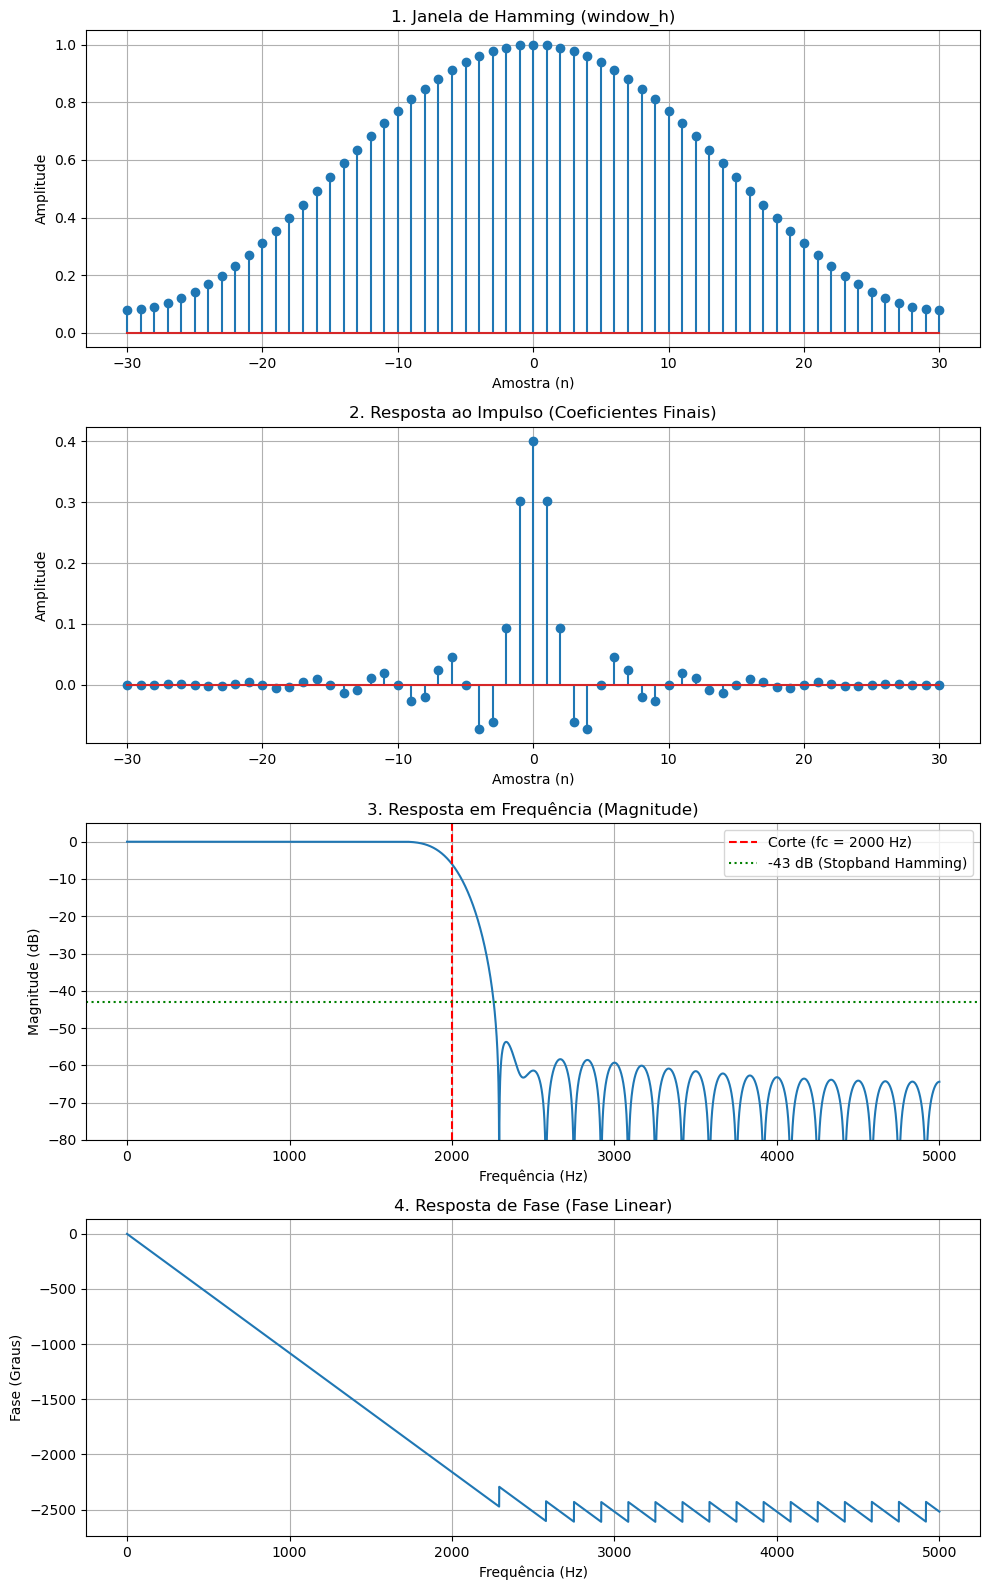

In [68]:
N = 61                # Ordem do filtro (tamanho)
fs = 10000            # Frequência de amostragem (12 kHz)
fc = 2000             # Frequência de corte (5 kHz)

# Cria o eixo de tempo 't' centrado em zero
t = np.arange(N) - (N - 1) / 2
# Calcula a função Sinc (nosso passa-baixa ideal)
h_LP = low_pass(N, fc, fs)
# Gera a janela de Hamming
window_h = hamming_window(N)
# Aplica a janela de Hamming à função Sinc
h_windowed = h_LP * window_h
# Normaliza os coeficientes do filtro
h_windowed /= np.sum(h_windowed)

t = np.arange(N) - (N - 1) / 2

w, H = freqz(h_windowed, 1, worN=8192, fs=fs)

# --- 5. Geração dos Gráficos em 'axs' ---
fig, axs = plt.subplots(4, 1, figsize=(10, 16)) 

# Gráfico 1: Janela de Hamming (NOVO)
axs[0].stem(t, window_h, 'o-')
axs[0].set_title("1. Janela de Hamming (window_h)")
axs[0].set_xlabel("Amostra (n)")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
# 

# Gráfico 2: Resposta ao Impulso (Coeficientes)
axs[1].stem(t, h_windowed, 'o-')
axs[1].set_title("2. Resposta ao Impulso (Coeficientes Finais)")
axs[1].set_xlabel("Amostra (n)")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True)

# Gráfico 3: Módulo em dB
magnitude_db = 20 * np.log10(np.abs(H))
axs[2].plot(w, magnitude_db)
axs[2].set_title("3. Resposta em Frequência (Magnitude)")
axs[2].set_xlabel("Frequência (Hz)")
axs[2].set_ylabel("Magnitude (dB)")
axs[2].axvline(fc, color='r', linestyle='--', label=f'Corte (fc = {fc} Hz)')
axs[2].axhline(-43, color='g', linestyle=':', label='-43 dB (Stopband Hamming)')
axs[2].set_ylim(-80, 5) 
axs[2].grid(True)
axs[2].legend()

# Gráfico 4: Fase (Desenrolada)
phase = np.unwrap(np.angle(H))
phase_degrees = np.rad2deg(phase)

axs[3].plot(w, phase_degrees)
axs[3].set_title("4. Resposta de Fase (Fase Linear)")
axs[3].set_xlabel("Frequência (Hz)")
axs[3].set_ylabel("Fase (Graus)")
axs[3].grid(True)

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()

        